# Analisis de artifact comparison

Este notebook carga `../artifacts/llm/artifact_comparison.json`, resume los mejores runs y genera graficas para estudiar que hiperparametros funcionan mejor.

In [1]:
import json
from pathlib import Path
from statistics import mean, pstdev

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "analysis" else Path.cwd().resolve()
INPUT_PATH = ROOT_DIR / "artifacts" / "llm" / "artifact_comparison.json"
OUTPUT_DIR = ROOT_DIR / "analysis" / "artifact_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HYPERPARAMS = [
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]
PRIMARY_METRIC = "bits_per_char_last_token"
SECONDARY_METRIC = "bits_per_char_all_tokens"
PRIMARY_PPL = "token_perplexity_last_token"
SECONDARY_PPL = "token_perplexity_all_tokens"

In [2]:
payload = json.loads(INPUT_PATH.read_text(encoding="utf-8"))
results = payload.get("results", [])
if not results:
    raise ValueError(f"No hay resultados en {INPUT_PATH}")

df = pd.DataFrame(results).sort_values(PRIMARY_METRIC).reset_index(drop=True)
df["run_name"] = df["run_dir"].map(lambda path: Path(path).name)

print(f"Runs evaluados: {len(df)}")
print(f"Runs saltados: {len(payload.get('skipped', []))}")
print(f"Mejor run: {df.iloc[0]['run_name']}")
print(f"Mejor bits_per_char_last_token: {df.iloc[0][PRIMARY_METRIC]:.6f}")

df.head()

Runs evaluados: 264
Runs saltados: 0
Mejor run: 20260424-181033
Mejor bits_per_char_last_token: 1.948881


,run_dir,vocab_size,seq_len,dim_embedding,dim_attention,num_heads,num_layers,batch_size,epochs,learning_rate,...,nll_per_char_last_token,bits_per_char_last_token,nll_per_token_all_tokens,token_perplexity_all_tokens,nll_per_char_all_tokens,bits_per_char_all_tokens,best_epoch,saved_val_loss,saved_perplexity,run_name
0,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,95,96,140,140,2,2,-1,-1,None,...,1.350861,1.948881,2.066006,7.893234,1.362001,1.964953,2,2.0684,7.91,20260424-181033
1,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,95,96,105,140,2,2,-1,-1,None,...,1.353106,1.952119,2.063672,7.874836,1.360463,1.962733,3,2.0660,7.89,20260424-174717
2,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,128,64,128,256,2,2,-1,-1,None,...,1.353849,1.953191,2.325207,10.228799,1.362447,1.965595,2,2.3260,10.24,20260424-012225
3,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,128,96,105,210,2,2,-1,-1,None,...,1.357943,1.959098,2.329687,10.274727,1.365072,1.969382,3,2.3304,10.28,20260424-202520
4,/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/2...,256,64,128,256,2,2,-1,-1,None,...,1.358554,1.959979,2.961022,19.317701,1.360264,1.962447,2,2.9635,19.37,20260424-071421


## Resumen del mejor modelo

In [3]:
best_run = df.iloc[0]
best_run[[
    "run_name",
    "bits_per_char_last_token",
    "token_perplexity_last_token",
    "bits_per_char_all_tokens",
    "token_perplexity_all_tokens",
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]]

run_name                       20260424-181033
bits_per_char_last_token              1.948881
token_perplexity_last_token            7.76097
bits_per_char_all_tokens              1.964953
token_perplexity_all_tokens           7.893234
vocab_size                                  95
seq_len                                     96
dim_embedding                              140
dim_attention                              140
num_heads                                    2
num_layers                                   2
Name: 0, dtype: object

## Top runs

In [4]:
top_n = 15
top_runs = df.head(top_n).copy()
top_runs[[
    "run_name",
    "bits_per_char_last_token",
    "token_perplexity_last_token",
    "bits_per_char_all_tokens",
    "token_perplexity_all_tokens",
    "vocab_size",
    "seq_len",
    "dim_embedding",
    "dim_attention",
    "num_heads",
    "num_layers",
]]

,run_name,bits_per_char_last_token,token_perplexity_last_token,bits_per_char_all_tokens,token_perplexity_all_tokens,vocab_size,seq_len,dim_embedding,dim_attention,num_heads,num_layers
0,20260424-181033,1.948881,7.760970,1.964953,7.893234,95,96,140,140,2,2
1,20260424-174717,1.952119,7.787442,1.962733,7.874836,95,96,105,140,2,2
2,20260424-012225,1.953191,10.079805,1.965595,10.228799,128,64,128,256,2,2
3,20260424-202520,1.959098,10.150486,1.969382,10.274727,128,96,105,210,2,2
4,20260424-071421,1.959979,19.245914,1.962447,19.317701,256,64,128,256,2,2
5,20260424-215423,1.962597,10.192587,1.955536,10.107799,128,128,140,140,2,2
6,20260424-220202,1.964251,10.212551,1.958952,10.148736,128,128,140,210,2,2
7,20260424-063939,1.964692,19.383248,1.961858,19.300563,256,64,128,80,2,2
8,20260424-115146,1.965739,26.588102,1.975314,27.016331,350,64,128,256,2,2
9,20260424-195541,1.966635,10.241393,1.978659,10.388101,128,96,70,140,2,2


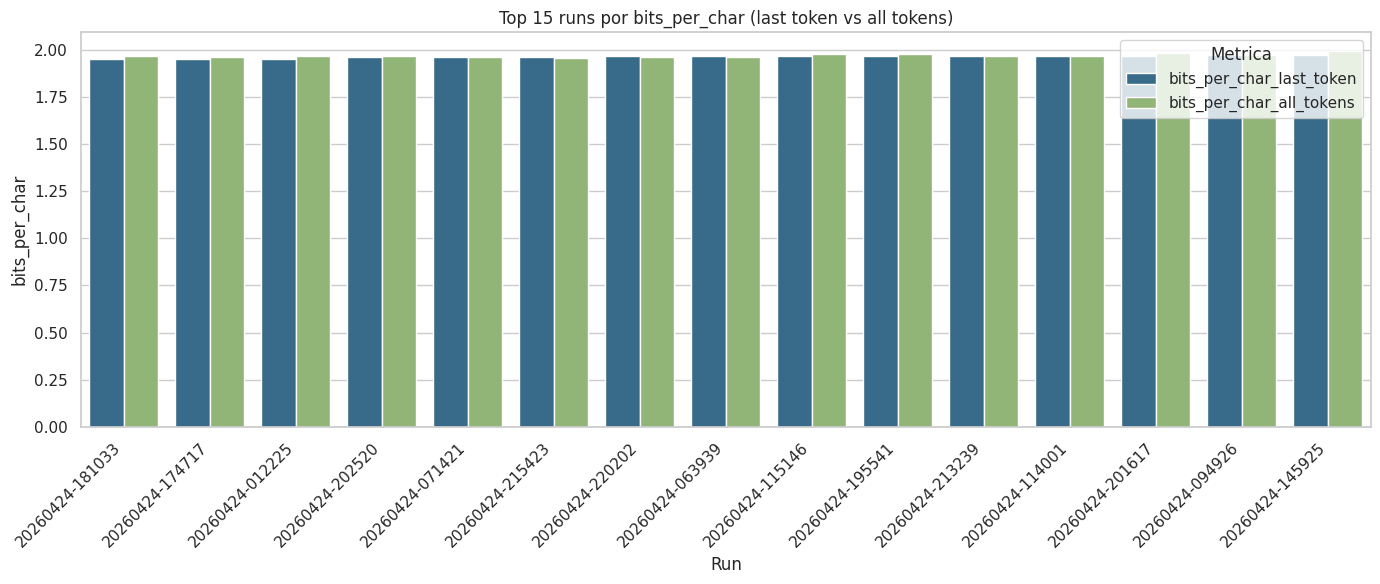

In [5]:
top_runs_plot = top_runs[["run_name", PRIMARY_METRIC, SECONDARY_METRIC]].melt(
    id_vars="run_name",
    value_vars=[PRIMARY_METRIC, SECONDARY_METRIC],
    var_name="metric",
    value_name="value",
)

metric_labels = {
    PRIMARY_METRIC: "bits_per_char_last_token",
    SECONDARY_METRIC: "bits_per_char_all_tokens",
}
top_runs_plot["metric"] = top_runs_plot["metric"].map(metric_labels)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_runs_plot,
    x="run_name",
    y="value",
    hue="metric",
    palette=["#2a6f97", "#90be6d"],
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Top {top_n} runs por bits_per_char (last token vs all tokens)")
plt.xlabel("Run")
plt.ylabel("bits_per_char")
plt.legend(title="Metrica")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_runs_dual_metrics.png", dpi=180)
plt.show()



## Impacto de cada hiperparametro

In [6]:
impact_rows = []
for param in HYPERPARAMS:
    grouped = df.groupby(param).agg({
        PRIMARY_METRIC: ["mean", "std", "min", "max", "count"],
        SECONDARY_METRIC: ["mean", "std", "min", "max", "count"],
    })
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    grouped = grouped.reset_index()

    grouped_primary = grouped.sort_values(f"{PRIMARY_METRIC}_mean")
    grouped_secondary = grouped.sort_values(f"{SECONDARY_METRIC}_mean")

    best_primary = grouped_primary.iloc[0]
    worst_primary = grouped_primary.iloc[-1]
    best_secondary = grouped_secondary.iloc[0]
    worst_secondary = grouped_secondary.iloc[-1]

    impact_rows.append({
        "param": param,
        "impact_range_last_token": worst_primary[f"{PRIMARY_METRIC}_mean"] - best_primary[f"{PRIMARY_METRIC}_mean"],
        "impact_range_all_tokens": worst_secondary[f"{SECONDARY_METRIC}_mean"] - best_secondary[f"{SECONDARY_METRIC}_mean"],
        "best_value_last_token": best_primary[param],
        "best_mean_last_token": best_primary[f"{PRIMARY_METRIC}_mean"],
        "worst_value_last_token": worst_primary[param],
        "worst_mean_last_token": worst_primary[f"{PRIMARY_METRIC}_mean"],
        "best_value_all_tokens": best_secondary[param],
        "best_mean_all_tokens": best_secondary[f"{SECONDARY_METRIC}_mean"],
        "worst_value_all_tokens": worst_secondary[param],
        "worst_mean_all_tokens": worst_secondary[f"{SECONDARY_METRIC}_mean"],
    })

impact_df = pd.DataFrame(impact_rows)
impact_df["max_impact_range"] = impact_df[["impact_range_last_token", "impact_range_all_tokens"]].max(axis=1)
impact_df = impact_df.sort_values("max_impact_range", ascending=False).drop(columns=["max_impact_range"])
impact_df



,param,impact_range_last_token,impact_range_all_tokens,best_value_last_token,best_mean_last_token,worst_value_last_token,worst_mean_last_token,best_value_all_tokens,best_mean_all_tokens,worst_value_all_tokens,worst_mean_all_tokens
1,seq_len,1.040348,0.986095,96.0,1.984552,1024.0,3.024901,96.0,1.988512,1024.0,2.974607
0,vocab_size,1.032268,0.987331,95.0,1.992633,6597.0,3.024901,95.0,1.987275,6597.0,2.974607
5,num_layers,0.928488,0.882930,2.0,2.096413,4.0,3.024901,2.0,2.091676,4.0,2.974607
4,num_heads,0.918411,0.871769,2.0,2.106490,8.0,3.024901,2.0,2.102838,8.0,2.974607
2,dim_embedding,0.320645,0.315073,105.0,1.984282,32.0,2.304927,140.0,1.982741,32.0,2.297814
3,dim_attention,0.252476,0.244155,140.0,1.988855,64.0,2.241330,140.0,1.985100,64.0,2.229255


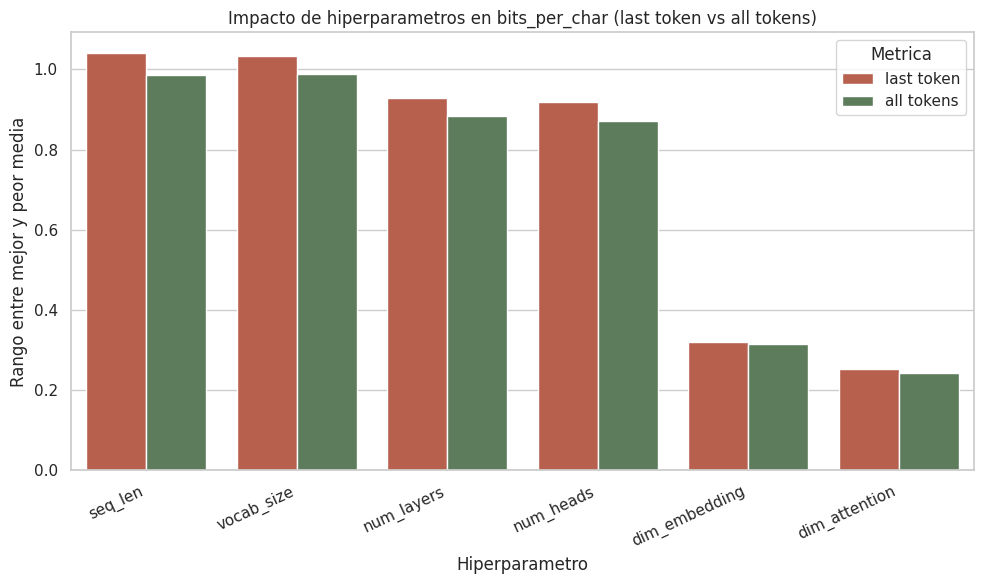

In [7]:
impact_plot = impact_df.melt(
    id_vars="param",
    value_vars=["impact_range_last_token", "impact_range_all_tokens"],
    var_name="metric",
    value_name="impact_range",
)

impact_metric_labels = {
    "impact_range_last_token": "last token",
    "impact_range_all_tokens": "all tokens",
}
impact_plot["metric"] = impact_plot["metric"].map(impact_metric_labels)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=impact_plot,
    x="param",
    y="impact_range",
    hue="metric",
    palette=["#c8553d", "#588157"],
)
plt.xticks(rotation=25, ha="right")
plt.title("Impacto de hiperparametros en bits_per_char (last token vs all tokens)")
plt.xlabel("Hiperparametro")
plt.ylabel("Rango entre mejor y peor media")
plt.legend(title="Metrica")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "param_impact_dual_metrics.png", dpi=180)
plt.show()



## Analisis por hiperparametro

,vocab_size,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
1,95,1.992633,0.021398,1.948881,2.019815,18,1.987275,0.016279,1.962733,2.017400,18
0,64,1.995985,0.017734,1.971470,2.035987,18,2.000809,0.010550,1.983421,2.018958,18
2,128,2.046451,0.120101,1.953191,2.537465,54,2.048334,0.118405,1.955536,2.541151,54
4,350,2.125780,0.190074,1.965739,2.836838,36,2.118654,0.188171,1.964735,2.826236,36
6,1000,2.126559,0.063673,2.040033,2.233962,32,2.118687,0.065353,2.035162,2.222838,32
5,512,2.217434,0.064313,2.093927,2.332560,32,2.204632,0.071845,2.086262,2.316751,32
3,256,2.220905,0.195307,1.959979,2.784827,73,2.212292,0.190542,1.961858,2.772042,73
7,6597,3.024901,NaN,3.024901,3.024901,1,2.974607,NaN,2.974607,2.974607,1


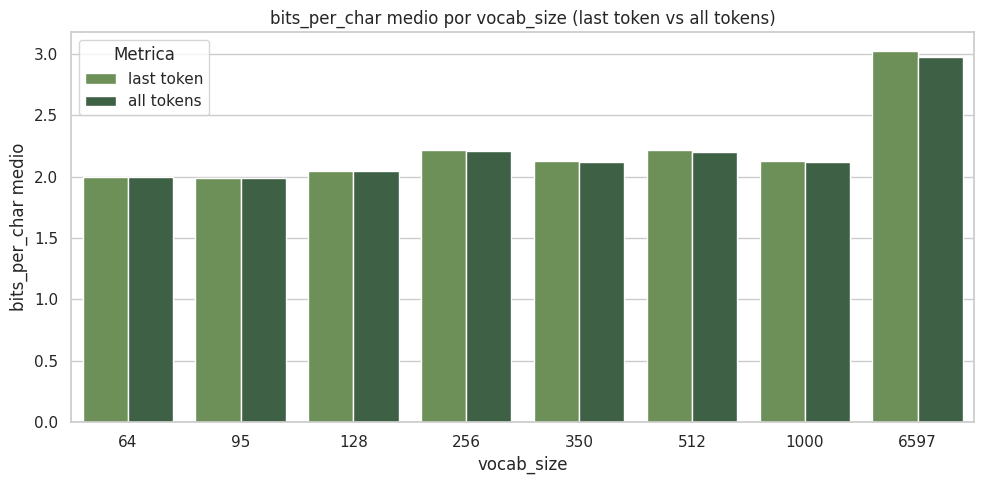

,seq_len,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
1,96,1.984552,0.019308,1.948881,2.020503,27,1.988512,0.016515,1.962733,2.018958,27
2,128,2.136931,0.169788,1.962597,2.836838,129,2.129544,0.168365,1.955536,2.826236,129
0,64,2.156247,0.156024,1.953191,2.513130,107,2.150557,0.149922,1.961858,2.518337,107
3,1024,3.024901,NaN,3.024901,3.024901,1,2.974607,NaN,2.974607,2.974607,1


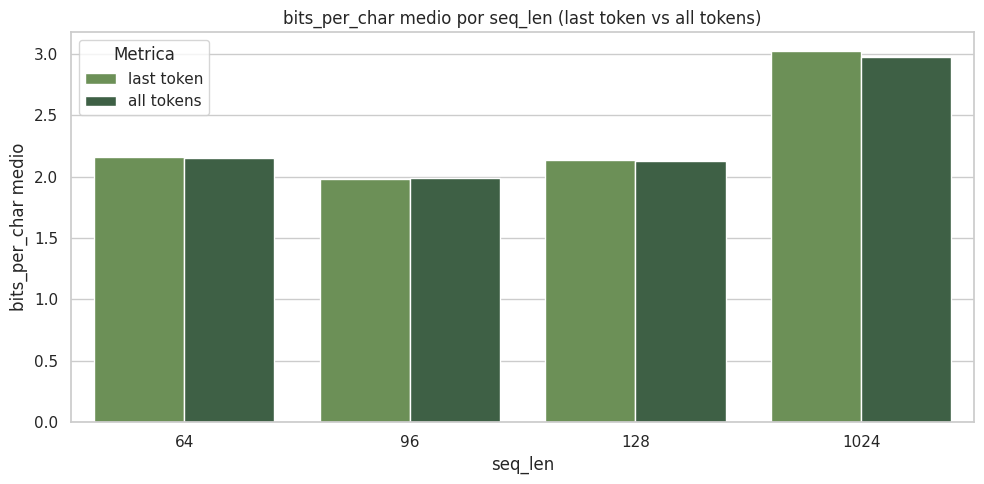

,dim_embedding,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
4,105,1.984282,0.021010,1.952119,2.035987,18,1.984613,0.012541,1.962733,2.004213,18
6,140,1.985262,0.018909,1.948881,2.020503,18,1.982741,0.016407,1.955536,2.005240,18
3,70,2.003844,0.033810,1.966635,2.125787,18,2.002762,0.014257,1.978193,2.027928,18
2,64,2.091602,0.091895,1.978625,2.378174,84,2.081552,0.084085,1.984726,2.369139,84
1,40,2.118521,0.109732,1.981550,2.307652,36,2.117539,0.093707,1.997952,2.282960,36
5,128,2.198564,0.279964,1.953191,3.024901,37,2.193438,0.277164,1.961858,2.974607,37
0,32,2.304927,0.122861,2.073489,2.513130,53,2.297814,0.119317,2.088095,2.518337,53


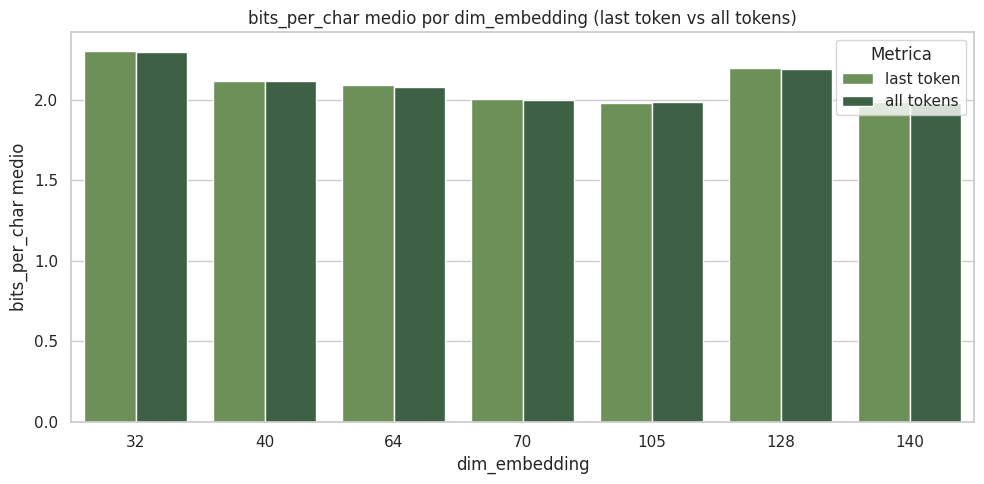

,dim_attention,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
3,140,1.988855,0.039752,1.948881,2.125787,18,1.985100,0.019439,1.955536,2.027928,18
6,280,1.989330,0.013866,1.971470,2.013541,18,1.995217,0.012604,1.972598,2.015736,18
4,210,1.995203,0.020008,1.959098,2.035987,18,1.989799,0.017254,1.958952,2.018958,18
1,80,2.078938,0.111583,1.964692,2.353765,36,2.077077,0.108251,1.961858,2.358610,36
5,256,2.157544,0.266596,1.953191,3.024901,37,2.152943,0.258504,1.962359,2.974607,37
2,128,2.166760,0.148680,1.968270,2.588444,84,2.159987,0.146292,1.964735,2.584804,84
0,64,2.241330,0.133855,2.040325,2.513130,53,2.229255,0.134026,2.035162,2.518337,53


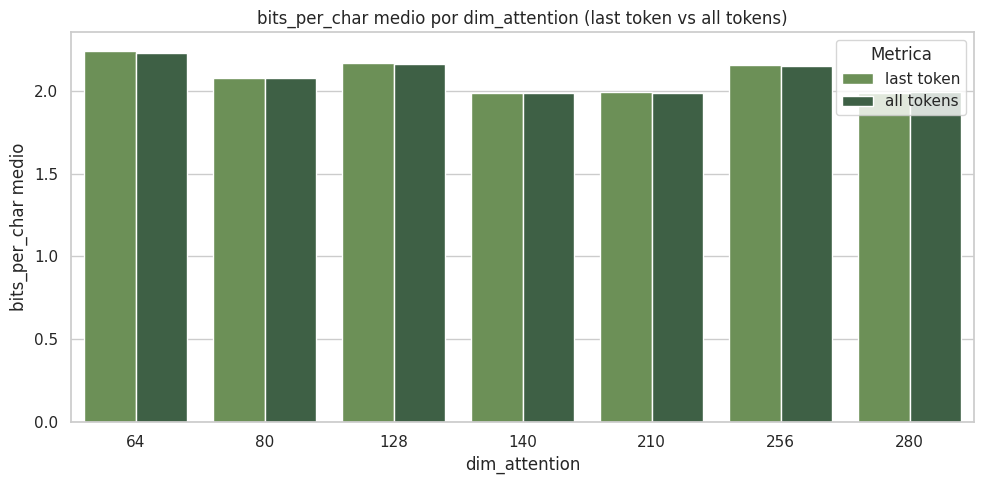

,num_heads,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
0,2,2.106490,0.161446,1.948881,2.836838,215,2.102838,0.157659,1.955536,2.826236,215
1,4,2.230625,0.126193,2.040325,2.489454,48,2.216676,0.127601,2.035162,2.479092,48
2,8,3.024901,NaN,3.024901,3.024901,1,2.974607,NaN,2.974607,2.974607,1


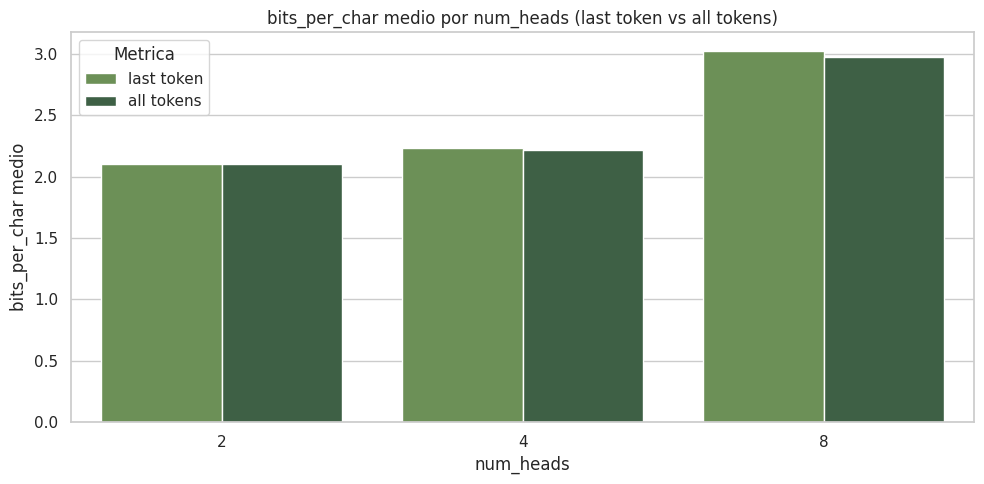

,num_layers,bits_per_char_last_token_mean,bits_per_char_last_token_std,bits_per_char_last_token_min,bits_per_char_last_token_max,bits_per_char_last_token_count,bits_per_char_all_tokens_mean,bits_per_char_all_tokens_std,bits_per_char_all_tokens_min,bits_per_char_all_tokens_max,bits_per_char_all_tokens_count
1,2,2.096413,0.153572,1.948881,2.836838,210,2.091676,0.149247,1.955536,2.826236,210
0,1,2.258843,0.130482,2.065331,2.513130,53,2.250161,0.129695,2.062334,2.518337,53
2,4,3.024901,NaN,3.024901,3.024901,1,2.974607,NaN,2.974607,2.974607,1


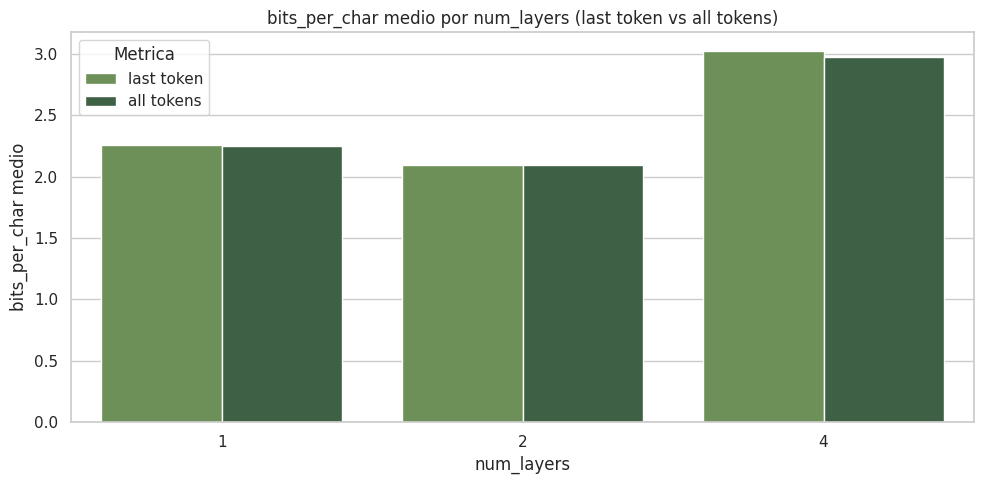

In [8]:
grouped_stats = {}
for param in HYPERPARAMS:
    stats = df.groupby(param).agg({
        PRIMARY_METRIC: ["mean", "std", "min", "max", "count"],
        SECONDARY_METRIC: ["mean", "std", "min", "max", "count"],
    })
    stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
    stats = stats.reset_index().sort_values(f"{PRIMARY_METRIC}_mean")
    grouped_stats[param] = stats
    display(stats)

    stats_plot = stats[[param, f"{PRIMARY_METRIC}_mean", f"{SECONDARY_METRIC}_mean"]].melt(
        id_vars=param,
        value_vars=[f"{PRIMARY_METRIC}_mean", f"{SECONDARY_METRIC}_mean"],
        var_name="metric",
        value_name="mean_value",
    )

    per_param_metric_labels = {
        f"{PRIMARY_METRIC}_mean": "last token",
        f"{SECONDARY_METRIC}_mean": "all tokens",
    }
    stats_plot["metric"] = stats_plot["metric"].map(per_param_metric_labels)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=stats_plot,
        x=param,
        y="mean_value",
        hue="metric",
        palette=["#6a994e", "#386641"],
    )
    plt.title(f"bits_per_char medio por {param} (last token vs all tokens)")
    plt.xlabel(param)
    plt.ylabel("bits_per_char medio")
    plt.legend(title="Metrica")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"metric_by_{param}_dual_metrics.png", dpi=180)
    plt.show()



## Relaciones entre dimensiones y calidad

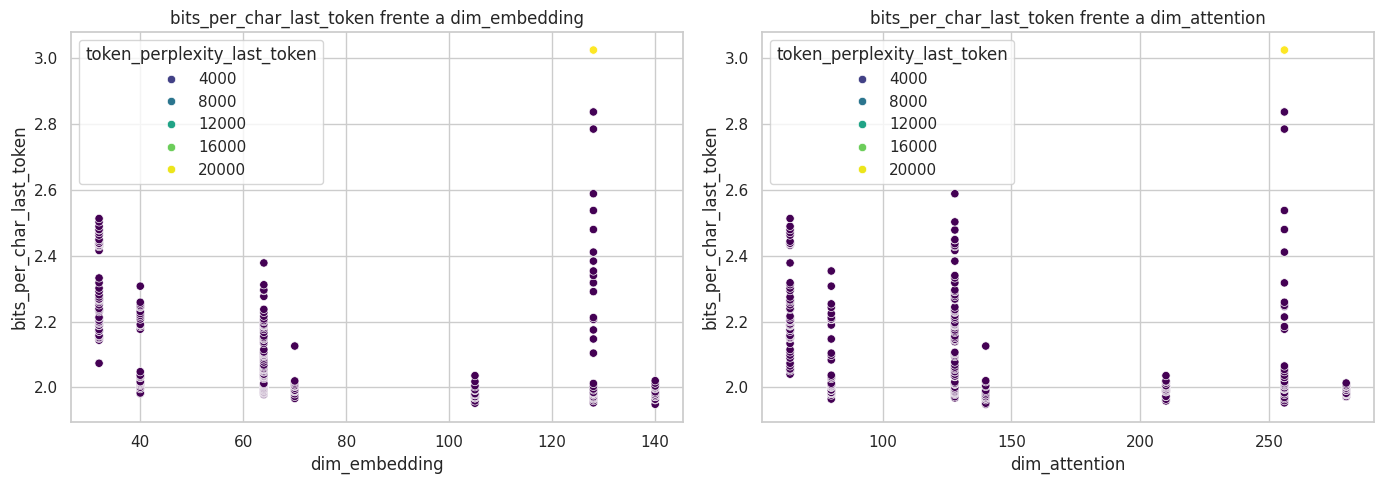

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="dim_embedding",
    y=PRIMARY_METRIC,
    hue=PRIMARY_PPL,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title(f"{PRIMARY_METRIC} frente a dim_embedding")

sns.scatterplot(
    data=df,
    x="dim_attention",
    y=PRIMARY_METRIC,
    hue=PRIMARY_PPL,
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title(f"{PRIMARY_METRIC} frente a dim_attention")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_dimensions_vs_bpc.png", dpi=180)
plt.show()

## Heatmaps

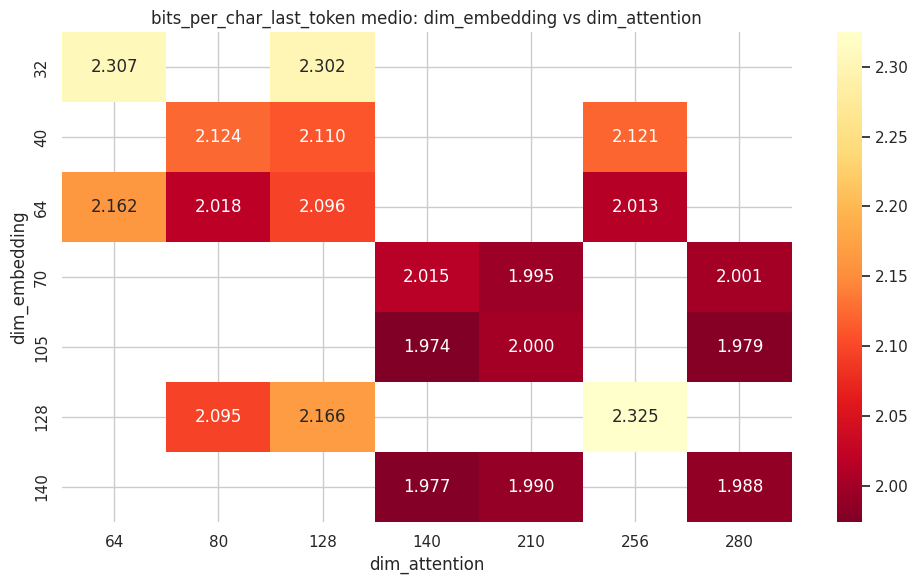

In [10]:
pivot_embedding_attention = df.pivot_table(
    values=PRIMARY_METRIC,
    index="dim_embedding",
    columns="dim_attention",
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_embedding_attention, annot=True, fmt=".3f", cmap="YlOrRd_r")
plt.title(f"{PRIMARY_METRIC} medio: dim_embedding vs dim_attention")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_embedding_attention.png", dpi=180)
plt.show()

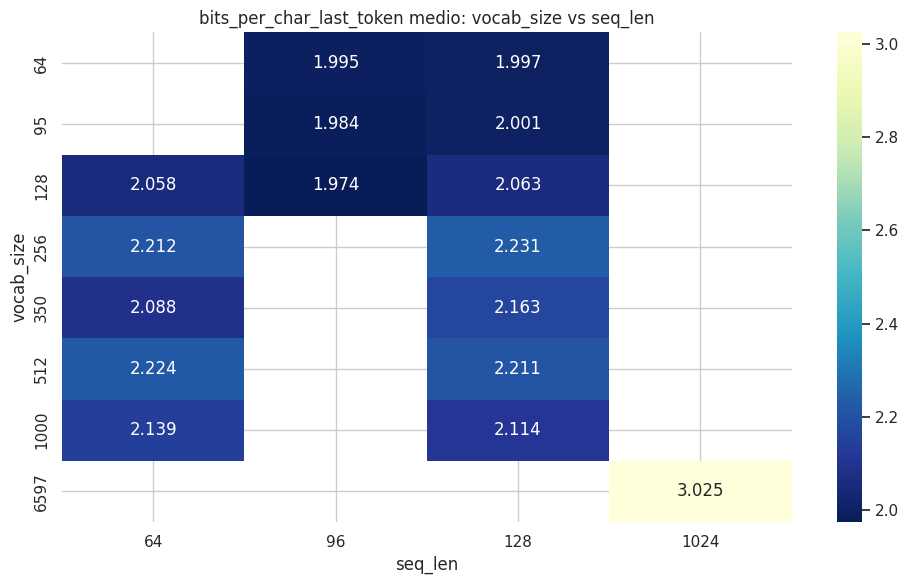

In [11]:
pivot_vocab_seq = df.pivot_table(
    values=PRIMARY_METRIC,
    index="vocab_size",
    columns="seq_len",
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_vocab_seq, annot=True, fmt=".3f", cmap="YlGnBu_r")
plt.title(f"{PRIMARY_METRIC} medio: vocab_size vs seq_len")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_vocab_seq_len.png", dpi=180)
plt.show()

## Recomendacion de hiperparametros

In [12]:
recommendation = {}
for param in HYPERPARAMS:
    grouped = df.groupby(param)[PRIMARY_METRIC].mean().sort_values()
    recommendation[param] = grouped.index[0]

recommendation

{'vocab_size': np.int64(95),
 'seq_len': np.int64(96),
 'dim_embedding': np.int64(105),
 'dim_attention': np.int64(140),
 'num_heads': np.int64(2),
 'num_layers': np.int64(2)}

In [13]:
summary_lines = [
    "# Analisis de artifact comparison",
    "",
    f"- Runs evaluados: {len(df)}",
    f"- Runs saltados: {len(payload.get('skipped', []))}",
    f"- Mejor run: {best_run['run_name']}",
    f"- Mejor bits_per_char_last_token: {best_run[PRIMARY_METRIC]:.6f}",
    f"- Mejor token_perplexity_last_token: {best_run[PRIMARY_PPL]:.6f}",
    f"- bits_per_char_all_tokens (mismo run): {best_run[SECONDARY_METRIC]:.6f}",
    f"- token_perplexity_all_tokens (mismo run): {best_run[SECONDARY_PPL]:.6f}",
    "",
    "## Recomendacion por media de hiperparametro",
    "",
]

for key, value in recommendation.items():
    summary_lines.append(f"- {key}: {value}")

(OUTPUT_DIR / "summary.md").write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
impact_df.to_json(OUTPUT_DIR / "impact_by_param.json", orient="records", force_ascii=False, indent=2)
print(f"Resumen guardado en {OUTPUT_DIR / 'summary.md'}")
print(f"Graficas guardadas en {OUTPUT_DIR}")

Resumen guardado en /home/hegarc04/pln/fdi-pln-2602/p5/analysis/artifact_analysis/summary.md
Graficas guardadas en /home/hegarc04/pln/fdi-pln-2602/p5/analysis/artifact_analysis
